In [150]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import hashlib

analising training images

In [151]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "train" / "NORMAL"
train_img = list(data_path.glob("*.jpeg"))
img_count = len(train_img)
print(f"Number of images in the data folder: {img_count}")

Number of images in the data folder: 1341


In [152]:
img_example = Image.open(train_img[0])
img_example.mode, img_example.size


('L', (2090, 1858))

Build the DataFrame

In [153]:
img_list = []
for img in train_img:
    with Image.open(img) as img_opened:
        width, height = img_opened.size
        img_list.append({
            "filename": img.name,
            "filepath": Path.relative_to(img, project_root),
            "width": width,
            "height": height,
            "mode": img_opened.mode
        })


In [154]:
df = pd.DataFrame(img_list)
df.head()

,filename,filepath,width,height,mode
0,IM-0115-0001.jpeg,data\train\NORMAL\IM-0115-0001.jpeg,2090,1858,L
1,IM-0117-0001.jpeg,data\train\NORMAL\IM-0117-0001.jpeg,1422,1152,L
2,IM-0119-0001.jpeg,data\train\NORMAL\IM-0119-0001.jpeg,1810,1434,L
3,IM-0122-0001.jpeg,data\train\NORMAL\IM-0122-0001.jpeg,1618,1279,L
4,IM-0125-0001.jpeg,data\train\NORMAL\IM-0125-0001.jpeg,1600,1125,L


In [155]:
df.shape

(1341, 5)

create the full DataFrame

In [156]:
def get_image_info(s,l):
    img_list_partial = []
    data_path = project_root / "data" / s / l
    img_list = list(data_path.glob("*.jpeg"))
    for img in img_list:
        with Image.open(img) as img_opened:
            width, height = img_opened.size
            img_list_partial.append({
                "filename": img.name,
                "filepath": Path.relative_to(img, project_root),
                "width": width,
                "height": height,
                "mode": img_opened.mode,
                "split": s,
                "label": l
            })
    return img_list_partial

In [157]:
split = ["train", "val", "test"]
label = ["NORMAL", "PNEUMONIA"]

img_list_complete = []
for s in split:
    for l in label:
        img_list_complete.extend(get_image_info(s, l))

In [158]:
df = pd.DataFrame(img_list_complete)
df.head()

,filename,filepath,width,height,mode,split,label
0,IM-0115-0001.jpeg,data\train\NORMAL\IM-0115-0001.jpeg,2090,1858,L,train,NORMAL
1,IM-0117-0001.jpeg,data\train\NORMAL\IM-0117-0001.jpeg,1422,1152,L,train,NORMAL
2,IM-0119-0001.jpeg,data\train\NORMAL\IM-0119-0001.jpeg,1810,1434,L,train,NORMAL
3,IM-0122-0001.jpeg,data\train\NORMAL\IM-0122-0001.jpeg,1618,1279,L,train,NORMAL
4,IM-0125-0001.jpeg,data\train\NORMAL\IM-0125-0001.jpeg,1600,1125,L,train,NORMAL


distribution of data

In [159]:
pd.crosstab(df["split"], df["label"],normalize="index", margins=True, margins_name="Total")

label,NORMAL,PNEUMONIA
split,,
test,0.375000,0.625000
train,0.257094,0.742906
val,0.500000,0.500000
Total,0.270321,0.729679


rgb image so need to convert to grayscale.

In [160]:
df["mode"].value_counts()

mode
L      5573
RGB     283
Name: count, dtype: int64

In [161]:
pd.crosstab(df["label"], df["mode"],normalize="index", margins=True, margins_name="Total")

mode,L,RGB
label,,
NORMAL,1.000000,0.000000
PNEUMONIA,0.933770,0.066230
Total,0.951673,0.048327


In [162]:
pd.crosstab(df["split"], df["mode"],normalize="index", margins=True, margins_name="Total")

mode,L,RGB
split,,
test,1.000000,0.000000
train,0.945744,0.054256
val,1.000000,0.000000
Total,0.951673,0.048327


In [163]:
rgb_all = df[df["mode"] == "RGB"].copy()

def channel_max_diff(path):
    arr = np.asarray(Image.open(project_root / path)).astype(np.int16)
    if arr.ndim != 3:
        return -1
    return max(np.abs(arr[..., 0] - arr[..., 1]).max(),
               np.abs(arr[..., 1] - arr[..., 2]).max())

rgb_all["chan_diff"] = rgb_all["filepath"].map(channel_max_diff)

print(rgb_all["chan_diff"].describe())

count    283.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: chan_diff, dtype: float64


need to set the image all of the same dimensions

In [164]:
df[["width", "height"]].describe()

,width,height
count,5856.000000,5856.000000
mean,1327.880806,970.689037
std,363.500922,383.392117
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1281.000000,888.000000
75%,1560.000000,1187.000000
max,2916.000000,2713.000000


In [165]:
df.groupby("label")[["width", "height"]].describe()

width                                                          \
            count         mean         std    min     25%     50%     75%   
label                                                                       
NORMAL     1583.0  1686.379659  305.316210  912.0  1472.0  1654.0  1848.0   
PNEUMONIA  4273.0  1195.069272  285.145232  384.0  1000.0  1160.0  1360.0   

                   height                                                  \
              max   count         mean         std    min     25%     50%   
label                                                                       
NORMAL     2916.0  1583.0  1378.648768  343.017920  496.0  1140.0  1323.0   
PNEUMONIA  2772.0  4273.0   819.553943  270.861725  127.0   640.0   776.0   

                           
              75%     max  
label                      
NORMAL     1554.0  2713.0  
PNEUMONIA   960.0  2304.0

In [166]:
df.groupby(["split", "label"])[["width", "height"]].describe()

width                                                   \
                  count         mean         std     min     25%     50%   
split label                                                                
test  NORMAL      234.0  1800.303419  365.930476   984.0  1533.0  1762.0   
      PNEUMONIA   390.0  1140.823077  208.858427   728.0   992.0  1111.0   
train NORMAL     1341.0  1667.734526  289.210512   912.0  1466.0  1640.0   
      PNEUMONIA  3875.0  1200.483613  291.305676   384.0  1000.0  1168.0   
val   NORMAL        8.0  1479.500000  221.727632  1240.0  1284.0  1446.0   
      PNEUMONIA     8.0  1217.000000  229.660619   968.0  1058.0  1172.0   

                                  height                                  \
                     75%     max   count         mean         std    min   
split label                                                                
test  NORMAL     2030.25  2752.0   234.0  1369.089744  429.178790  496.0   
      PNEUMONIA  1256.00  2000.0   390.0   765.289744  193.097470  344.0   
train NORMAL     1824.00  2916.0  1341.0  1381.431022  326.320734  672.0   
      PNEUMONIA  1368.00  2772.0  3875.0   825.026839  277.073758  127.0   
val   NORMAL     1658.00  1776.0     8.0  1191.875000  178.016402  928.0   
      PNEUMONIA  1296.00  1664.0     8.0   814.000000  186.774119  592.0   

                                                  
                    25%     50%      75%     max  
split label                                       
test  NORMAL     1040.0  1317.5  1638.75  2713.0  
      PNEUMONIA   632.0   736.0   871.75  1456.0  
train NORMAL     1152.0  1328.0  1542.00  2663.0  
      PNEUMONIA   640.0   776.0   968.00  2304.0  
val   NORMAL     1088.0  1164.5  1330.50  1416.0  
      PNEUMONIA   662.0   788.0   946.00  1128.0

In [167]:
df["aspect_ratio"] = df["width"] / df["height"]
df.groupby(["split", "label"])["aspect_ratio"].describe()

count      mean       std       min       25%       50%  \
split label                                                                 
test  NORMAL      234.0  1.368092  0.208978  0.927755  1.213080  1.353099   
      PNEUMONIA   390.0  1.527349  0.219128  1.000000  1.381759  1.506251   
train NORMAL     1341.0  1.227792  0.129719  0.877220  1.138389  1.222806   
      PNEUMONIA  3875.0  1.513755  0.249553  0.835391  1.352381  1.487500   
val   NORMAL        8.0  1.243849  0.082362  1.123188  1.202481  1.224533   
      PNEUMONIA     8.0  1.513182  0.140760  1.252101  1.469809  1.502809   

                      75%       max  
split label                          
test  NORMAL     1.517763  2.106969  
      PNEUMONIA  1.657330  2.581395  
train NORMAL     1.311209  1.807923  
      PNEUMONIA  1.643671  3.378788  
val   NORMAL     1.273739  1.387931  
      PNEUMONIA  1.570369  1.734940

In [168]:


tiny = df[df[["width", "height"]].min(axis=1) < 300].copy()
tiny["min_side"] = tiny[["width", "height"]].min(axis=1)

print(f"Image with side < 300 px: {len(tiny)} su {len(df)}  ({len(tiny)/len(df):.2%})")

display(tiny.groupby(["label", "split"]).size().rename("n"))


Image with side < 300 px: 76 su 5856  (1.30%)


label      split
PNEUMONIA  train    76
Name: n, dtype: int64

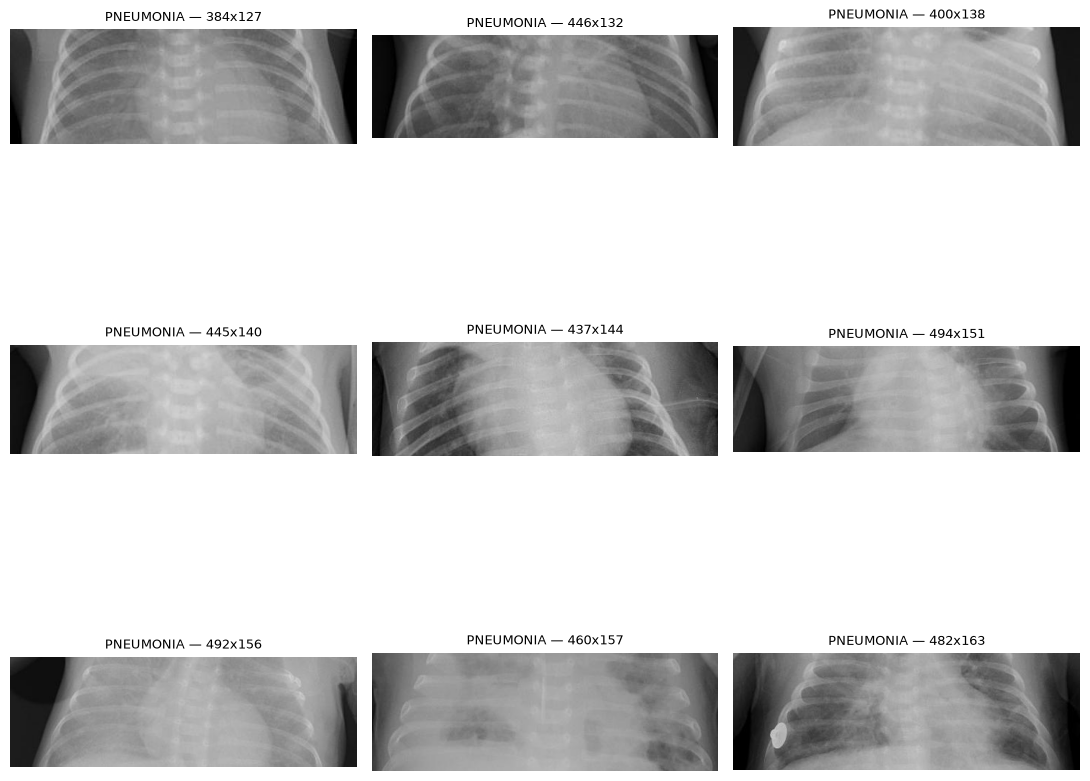

In [169]:
sample = tiny.sort_values("min_side").head(9)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    with Image.open(project_root / row["filepath"]) as im:
        ax.imshow(im, cmap="gray")
    ax.set_title(f'{row["label"]} — {row["width"]}x{row["height"]}', fontsize=9)
    ax.axis("off")
plt.tight_layout()

save all

In [170]:
inventory_path = project_root / "experiments" / "image_inventory.csv"

df_to_save = df.copy()
df_to_save["filepath"] = df_to_save["filepath"].map(lambda p: Path(p).as_posix())

df_to_save.to_csv(inventory_path, index=False)

adding 2 columns

In [171]:
def parse_meta(filename, label, split):

    if label == "NORMAL":
        name = filename.rsplit(".", 1)[0]
        parts = name.split("-")
        if "NORMAL" in parts[0]:
            patientid = split + "_" + parts[1] + "_" + parts[2]
            return patientid, None
        patientid = split + "_" + parts[0] + "_" + parts[1]
        return patientid, None
    
    name = filename.rsplit(".", 1)[0]
    parts = name.split("_")
    if len(parts) < 3:
        return None, None

    patientid = split + "_" + parts[0]
    typeid = parts[1]
    
    return patientid, typeid

In [172]:
parse_meta("IM-12345-1232.jpeg", "NORMAL", "train")

('train_IM_12345', None)

In [173]:
df[["patientid", "typeid"]] = df.apply(
    lambda row: parse_meta(row["filename"], row["label"], row["split"]),
    axis=1
).apply(pd.Series)
df[df["patientid"].notna()].head(10)


,filename,filepath,width,height,mode,split,label,aspect_ratio,patientid,typeid
0,IM-0115-0001.jpeg,data\train\NORMAL\IM-0115-0001.jpeg,2090,1858,L,train,NORMAL,1.124865,train_IM_0115,NaN
1,IM-0117-0001.jpeg,data\train\NORMAL\IM-0117-0001.jpeg,1422,1152,L,train,NORMAL,1.234375,train_IM_0117,NaN
2,IM-0119-0001.jpeg,data\train\NORMAL\IM-0119-0001.jpeg,1810,1434,L,train,NORMAL,1.262204,train_IM_0119,NaN
3,IM-0122-0001.jpeg,data\train\NORMAL\IM-0122-0001.jpeg,1618,1279,L,train,NORMAL,1.265051,train_IM_0122,NaN
4,IM-0125-0001.jpeg,data\train\NORMAL\IM-0125-0001.jpeg,1600,1125,L,train,NORMAL,1.422222,train_IM_0125,NaN
5,IM-0127-0001.jpeg,data\train\NORMAL\IM-0127-0001.jpeg,1974,1306,L,train,NORMAL,1.511485,train_IM_0127,NaN
6,IM-0128-0001.jpeg,data\train\NORMAL\IM-0128-0001.jpeg,1528,1013,L,train,NORMAL,1.508391,train_IM_0128,NaN
7,IM-0129-0001.jpeg,data\train\NORMAL\IM-0129-0001.jpeg,1384,1167,L,train,NORMAL,1.185947,train_IM_0129,NaN
8,IM-0131-0001.jpeg,data\train\NORMAL\IM-0131-0001.jpeg,1450,1144,L,train,NORMAL,1.267483,train_IM_0131,NaN
9,IM-0133-0001.jpeg,data\train\NORMAL\IM-0133-0001.jpeg,1468,993,L,train,NORMAL,1.478348,train_IM_0133,NaN


checking leakage by hashing, names don't cover all the imgs

In [174]:
def file_hash(relpath):
    return hashlib.md5((project_root / relpath).read_bytes()).hexdigest()

In [175]:
df["file_hash"] = df["filepath"].map(file_hash)
df.head()

,filename,filepath,width,height,mode,split,label,aspect_ratio,patientid,typeid,file_hash
0,IM-0115-0001.jpeg,data\train\NORMAL\IM-0115-0001.jpeg,2090,1858,L,train,NORMAL,1.124865,train_IM_0115,NaN,20e1b8286b2d4e7a9869d42abd1cbf91
1,IM-0117-0001.jpeg,data\train\NORMAL\IM-0117-0001.jpeg,1422,1152,L,train,NORMAL,1.234375,train_IM_0117,NaN,9299d3c610ad02c31c30469c9a4c2431
2,IM-0119-0001.jpeg,data\train\NORMAL\IM-0119-0001.jpeg,1810,1434,L,train,NORMAL,1.262204,train_IM_0119,NaN,4b873c9f031149dccd93d51e092215ca
3,IM-0122-0001.jpeg,data\train\NORMAL\IM-0122-0001.jpeg,1618,1279,L,train,NORMAL,1.265051,train_IM_0122,NaN,f510c0d0ff70e725449ecbdf93553a70
4,IM-0125-0001.jpeg,data\train\NORMAL\IM-0125-0001.jpeg,1600,1125,L,train,NORMAL,1.422222,train_IM_0125,NaN,3c0c7a39407e411aa83b854f8f8fa8f0


In [176]:
splits = df.groupby("file_hash")["split"].nunique()
print((splits > 1).sum())

0


In [177]:
counts = df["patientid"].value_counts()

print(counts[counts == 3])

patientid
train_IM_0435     3
train_IM_0453     3
train_IM_0467     3
train_IM_0505     3
train_IM_0517     3
                 ..
test_person175    3
test_person3      3
test_person88     3
test_person94     3
test_person96     3
Name: count, Length: 251, dtype: int64


also checking if the groupby on the patient name could be usefull

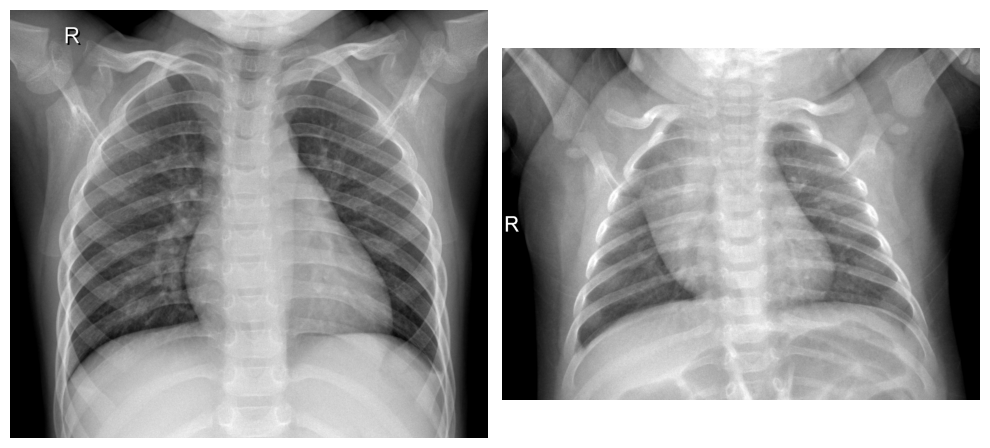

In [178]:
img1_row = df[df["filename"] == "IM-0555-0001.jpeg"].iloc[0]
img2_row = df[df["filename"] == "NORMAL2-IM-0555-0001.jpeg"].iloc[0]
img1 = Image.open(project_root / img1_row["filepath"])
img2 = Image.open(project_root / img2_row["filepath"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1, cmap="gray")
axes[0].axis("off")
axes[1].imshow(img2, cmap="gray")
axes[1].axis("off")

plt.tight_layout()
plt.show()

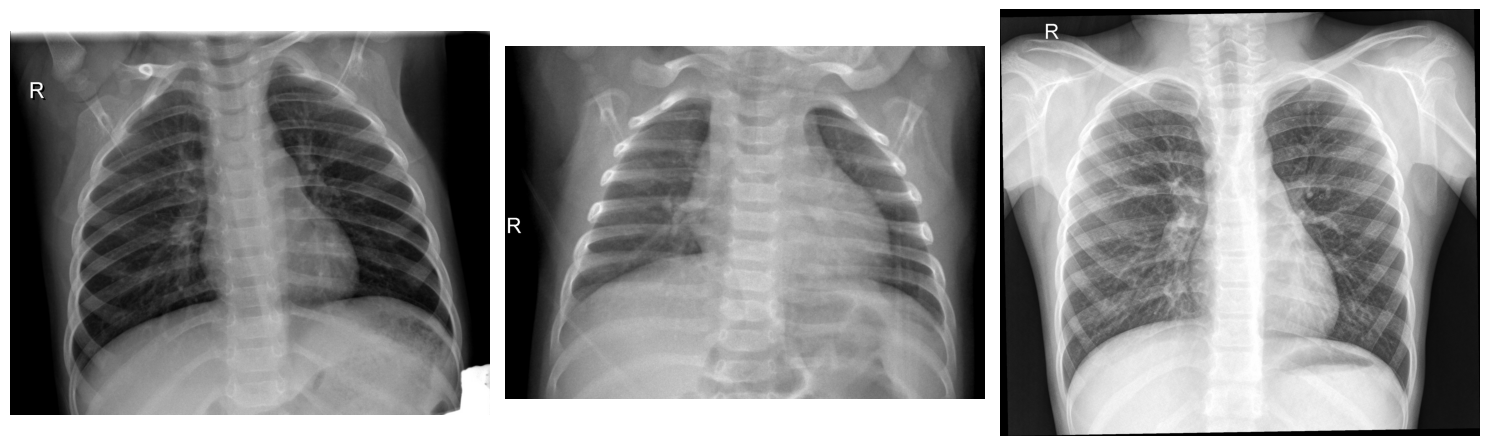

In [179]:
img1_row = df[df["filename"] == "IM-0435-0001-0001.jpeg"].iloc[0]
img2_row = df[df["filename"] == "IM-0435-0001.jpeg"].iloc[0]
img3_row = df[df["filename"] == "NORMAL2-IM-0435-0001.jpeg"].iloc[0]

img1 = Image.open(project_root / img1_row["filepath"])
img2 = Image.open(project_root / img2_row["filepath"])
img3 = Image.open(project_root / img3_row["filepath"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1, cmap="gray")
axes[0].axis("off")
axes[1].imshow(img2, cmap="gray")
axes[1].axis("off")
axes[2].imshow(img3, cmap="gray")
axes[2].axis("off")

plt.tight_layout()
plt.show()

only watching is not enought

gruppi: 271   immagini: 644
osservato : 320
nullo     : mediana 346   minimo 302
permutazioni con valore <= osservato: 0.135


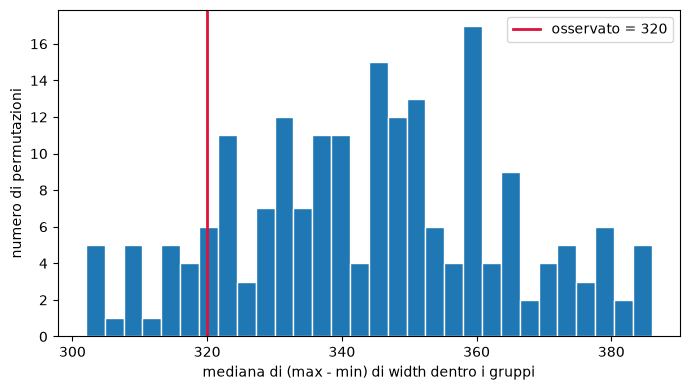

In [180]:
import numpy as np
import matplotlib.pyplot as plt

COL = "width"        # rilancia poi con "aspect_ratio"
N_PERM = 200
rng = np.random.default_rng(42)

# only Normal images that are in groups with at least 2 images
norm = df[df["label"] == "NORMAL"].copy()
norm = norm[norm.groupby("patientid")["filename"].transform("size") >= 2]

def median_spread(keys, values):
    """mediana di (max - min) calcolata dentro ogni gruppo"""
    g = pd.DataFrame({"k": keys, "v": values})
    agg = g.groupby("k")["v"].agg(["max", "min"])
    return (agg["max"] - agg["min"]).median()

keys = norm["patientid"].to_numpy()
values = norm[COL].to_numpy()

observed = median_spread(keys, values)
null = np.array([median_spread(rng.permutation(keys), values) for _ in range(N_PERM)])

quota = (null <= observed).mean()
print(f"gruppi: {norm['patientid'].nunique()}   immagini: {len(norm)}")
print(f"osservato : {observed:.4g}")
print(f"nullo     : mediana {np.median(null):.4g}   minimo {null.min():.4g}")
print(f"permutazioni con valore <= osservato: {quota:.3f}")

plt.figure(figsize=(7, 4))
plt.hist(null, bins=30, edgecolor="white")
plt.axvline(observed, color="crimson", lw=2, label=f"osservato = {observed:.4g}")
plt.xlabel(f"mediana di (max - min) di {COL} dentro i gruppi")
plt.ylabel("numero di permutazioni")
plt.legend()
plt.tight_layout()


13.5% of the random groupings perform just as well or better. If the key were capturing something real, the observed result would stand out from the pack, with a value close to zero. It sits just below the median, which is what one expects from chance.